<!-- COLAB-BADGE -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB03_PseudocodeFlowcharts.ipynb)  
[Download .ipynb](https://raw.githubusercontent.com/brendanpshea/computing_concepts_python/main/v2/notebooks/COMP1150_NB03_PseudocodeFlowcharts.ipynb) · [View on GitHub](https://github.com/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB03_PseudocodeFlowcharts.ipynb)


# Notebook 3: Python Basics via Pseudocode & Flowcharts
### COMP 1150 — Computer Science Concepts
**Brendan Shea, PhD**

📺 **Lecture video:** *(link coming soon)*

## Learning Outcomes

By the end of this notebook, you will be able to:

- **Declare** variables and identify the four core data types (`int`, `float`, `str`, `bool`)
- **Evaluate** expressions using arithmetic, comparison, and boolean operators, including compound conditions
- **Format** output using f-strings, escape characters, and string methods
- **Convert** between types correctly and read input
- **Write** clear pseudocode and read a flowchart
- **Follow** the workflow problem → pseudocode → flowchart → Python on a real problem
- **Trace** a short program by hand and use AI as a reviewer of your plan

*Maps to course LOs: 5 (pseudocode & flowcharts) and 6 (constructing Python to implement algorithmic solutions)*

## The Counting-House

Welcome to the counting-house of **Scrooge & Marley**, where the ledgers are long, the candles are short, and a single misplaced number has consequences.

**Ebenezer Scrooge**, the managing partner — who rounds every total in the firm's favour — has a complaint. His clerk, **Bob Cratchit**, computes every sum by hand, by candlelight, and humans make mistakes. Scrooge wants the arithmetic done by machine: exactly, repeatably, the same way every time.

So far you've *read* code. Notebooks 1 and 2 both ended with the same promise: you'd learn the workflow this whole course runs on — **problem → pseudocode → flowchart → Python**. This is that notebook. By the end you will take a plain-English problem from Scrooge and turn it into working code, deliberately, step by step — the way Cratchit's colleague **Esther Summerson** does it: she writes down exactly what she intends to do *before* she does any of it.

## The Roadmap

| Part | What you'll learn |
|---|---|
| Variables & types | How a program stores a value, and what kind it is |
| Operators & expressions | Arithmetic, comparison, and compound boolean logic |
| Input & output | How a program talks to a person (and the #1 beginner bug) |
| Printing well | Escape characters, f-string formatting, string methods |
| The workflow | Problem → pseudocode → flowchart → Python, start to finish |
| Building with AI | Plan by hand, let the AI critique the plan, then build |

**Scope note:** this notebook is **sequential only** — every program runs straight down, top to bottom. *Decisions* and *repetition* (if-statements and loops) are Notebook 4. We'll point at that door but not walk through it.

One idea carries over from Notebook 2 and runs through everything below: **a value lives in a box of a fixed kind.** There, the box was a byte. Here, the box has a *name* — and the name is how your program reaches it.

## How to Experiment in This Notebook

This is a **tinkering** notebook, not a reading one. Most code cells start with a block like this:

```python
# ⬇️ CHANGE THESE, THEN RE-RUN
coins = 50
```

**Change the values, press Shift + Enter, and watch what happens.** That is how you actually learn what code does — by poking it. We also teach the `input()` function, because it's a real tool and a real source of bugs, but while you're *learning*, editing the values directly is faster and won't pause the notebook waiting for you to type.

## Variables: Named Boxes

A **variable** is a labelled box that holds one value. You put a value in with the **assignment operator**, `=`.

Read `=` as *"gets"*, not *"equals"*. `coins = 50` means **"the box named `coins` gets the value 50."** It is an instruction, not a statement of fact.

Scrooge likes this: a named box can be checked, reused, and corrected in exactly one place. Cratchit's hand-written totals were scattered down a page; a variable is one labelled box he can always find.

In [1]:
# ⬇️ CHANGE THESE, THEN RE-RUN
coins = 50
debts = 12
# ----------------------------------

coins = coins - debts    # compute on the right, store back into 'coins'

print(coins)

38


### Understanding the Code

- `coins = 50` — create the box `coins`, put `50` in it.
- `coins = coins - debts` — the line beginners misread. The **right side runs first**: Python computes `50 - 12 = 38`. *Then* the result is stored back into `coins`, replacing the old value.
- A variable always holds whatever was assigned **most recently**. Earlier values are gone.
- Try it: set `debts = 60` and re-run. `coins` goes negative — the program doesn't object. Numbers are just numbers to it.

### Picture It: the Right Side Runs First

The diagram below shows what `coins = coins - debts` actually does: Python computes the expression on the right, *then* drops the result into the named box.

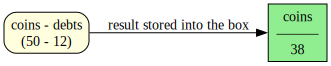

In [2]:
from graphviz import Digraph

d = Digraph(graph_attr={"rankdir": "LR"})
d.node("E", "coins - debts\n(50 - 12)", shape="box",
       style="rounded,filled", fillcolor="lightyellow")
d.node("B", "coins\n―――\n38", shape="box",
       style="filled", fillcolor="lightgreen")
d.edge("E", "B", label=" result stored into the box ")
d

**Reading it:** the yellow box is the expression Python evaluates first; the arrow is the assignment; the green box is `coins` after it's been updated. `=` always flows right → left.

## Data Types: What Kind of Value?

Every value has a **type**. **Mr. Gradgrind**, who runs a nearby school on Facts and refuses to believe a child can be 2.5 children, insists you always know which type you're holding. The four you need now:

| Type | Name | Example | Used for |
|---|---|---|---|
| `int` | integer | `42`, `-7` | whole numbers (counts, pennies) |
| `float` | floating-point | `3.14`, `2.0` | numbers with a decimal point |
| `str` | string | `"Cratchit"` | text, in quotes |
| `bool` | boolean | `True`, `False` | yes/no answers |

The type decides what operations make sense. Python's `type()` function tells you what you're holding.

In [3]:
print(type(42))            # whole number
print(type(3.14))          # has a decimal point
print(type("Cratchit"))    # in quotes -> text
print(type(7 > 3))         # a comparison -> True/False
print(type("42"))          # quotes! looks numeric, is text

# ⬇️ CHANGE THIS and re-run to test your own guess:
mystery = 9.0
print("mystery is:", type(mystery))

<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>
<class 'str'>
mystery is: <class 'float'>


### Understanding the Code

- `type(42)` is `int`; `type(3.14)` is `float`. The **decimal point** is the whole difference — `2` is an `int`, `2.0` is a `float`.
- `type("Cratchit")` is `str`. **Quotes make it text**, always.
- `type(7 > 3)` is `bool`. Comparisons evaluate to `True`/`False` — the same 1/0 logic-gate outputs from Notebook 2, now with names.
- `type("42")` is `str`, **not** `int`. This is Gradgrind's nightmare and the source of the most common beginner bug. *Quotes win.*

Two habits, starting now: (1) when a program misbehaves, ask *"what type is this, really?"* first; (2) never trust that something is a number just because it looks like one.

## Operators & Expressions

An **expression** is anything that computes a value. `coins - debts` is an expression; so is `7 > 3`.

**Arithmetic:** `+  -  *  /` and three you must not skip:

| Operator | Meaning | Example | Result |
|---|---|---|---|
| `/` | true division (always a `float`) | `7 / 2` | `3.5` |
| `//` | floor division (whole part only) | `7 // 2` | `3` |
| `%` | modulo (the remainder) | `7 % 2` | `1` |
| `**` | exponent | `2 ** 3` | `8` |

In [4]:
# ⬇️ CHANGE THIS, THEN RE-RUN
pennies = 47
# ----------------------------------

print(pennies / 10)     # true division -> 4.7   (a float)
print(pennies // 10)    # floor division -> 4    (whole tens)
print(pennies % 10)     # modulo -> 7            (leftover pennies)
print(pennies ** 2)     # exponent -> 2209

4.7
4
7
2209


### Understanding the Code

- `pennies / 10` is `4.7` — `/` **always** gives a `float`, even when it divides evenly (`10 / 5` is `5.0`).
- `pennies // 10` is `4` and `pennies % 10` is `7`. Together they answer *"how many whole tens, and how many left over?"* — `4` tens, `7` spare pennies. This pair is the heart of today's worked example, so make sure it clicks.
- Vocabulary: the whole line is a **statement**; the part producing a value is an **expression**; `+`, `//`, `**` are **operators**; the values they act on are **operands**.

## Basic Python Math Functions (Counting-House Toolkit)

Scrooge likes operators (`+`, `-`, `*`, `/`), but a clerk also needs a few **built-in math functions** for tidy ledger work.

| Function | What it does | Example | Result |
|---|---|---|---|
| `abs(x)` | Absolute value (distance from 0) | `abs(coins)` | `38` |
| `round(x, n)` | Round to `n` decimal places | `round(price, 1)` | `19.5` |
| `min(...)` | Smallest value | `min(hours, debts, qty)` | `8` |
| `max(...)` | Largest value | `max(hours, debts, qty)` | `40` |
| `pow(a, b)` | Exponent (`a` to the power `b`) | `pow(heirs, 2)` | `16` |
| `sum([...])` | Add a collection of numbers | `sum([qty, debts, heirs])` | `24` |
| `divmod(a, b)` | Quotient and remainder together | `divmod(total, heirs)` | `(810, 3)` |

### Why this matters in our workflow

- These functions are just like operators: they **compute values** you can store in variables.
- `divmod(total, heirs)` is the one-line form of the estate split (`//` and `%`) used later in this notebook.
- In reporting cells, combine these with f-strings to present clean, readable results.

In [20]:
# Code demonstratin math functions from previous cell
print(pow(5, 3))       # 5 to the power of 3 -> 125
print(abs(-42))       # absolute value -> 42
print(round(3.14159, 2))  # round to 2 decimal places
print(max(10, 20, 5))   # maximum of the numbers -> 20
print(min(10, 20, 5))   # minimum of the numbers ->


125
42
3.14
20
5


### Comparison & Boolean Operators

**Comparison** operators evaluate two values and return a boolean result (`True` or `False`).

| Operator | Meaning | Example | Result |
|---|---|---|---|
| `==` | equal to | `7 == 7` | `True` |
| `!=` | not equal to | `7 != 5` | `True` |
| `<` | less than | `3 < 2` | `False` |
| `>` | greater than | `10 > 4` | `True` |
| `<=` | less than or equal to | `5 <= 5` | `True` |
| `>=` | greater than or equal to | `9 >= 12` | `False` |

You can store comparison results in variables (for example, `passed = score >= 50`) and combine them with boolean operators in the next section.

> Important: `==` checks whether two values are equal, while `=` assigns a value to a variable.  
> `score == 50` is a test; `score = 50` is an assignment.



**Boolean** operators combine `True`/`False` values — they are the AND/OR/NOT gates from Notebook 2, spelled as words:

| `A` | `B` | `A and B` | `A or B` | `not A` |
|---|---|---|---|---|
| F | F | F | F | T |
| F | T | F | T | T |
| T | F | F | T | F |
| T | T | **T** | **T** | F |

- `and` — True only if **both** sides are True
- `or` — True if **either** side is True
- `not` — flips it

In [5]:
# ⬇️ CHANGE THESE, THEN RE-RUN
score = 72
has_bonus = True
# ----------------------------------

print(score >= 50)                      # one comparison -> bool
print(score >= 50 and score <= 100)     # both must be True
print(score < 50 or has_bonus)          # either is enough
print(not has_bonus)                    # flip it
print(not (score >= 50 and has_bonus))  # parentheses first

True
True
True
False
False


### Understanding the Code

Evaluate a compound condition the way Python does — **innermost and simplest first**. With `score = 72`, `has_bonus = True`:

- `score >= 50 and score <= 100`
  1. `72 >= 50` → `True`
  2. `72 <= 100` → `True`
  3. `True and True` → **`True`**
- `not (score >= 50 and has_bonus)`
  1. `72 >= 50` → `True`; `has_bonus` is `True`
  2. `True and True` → `True`
  3. `not True` → **`False`**

**Precedence (what binds tightest):** arithmetic → comparisons → `not` → `and` → `or`. When in doubt, add parentheses; Python evaluates the innermost ones first, and so should you.

### A Practice Game: Trace Arcade

Tracing code — running it in your head, line by line — is the single most important skill for the rest of this course. The game below has **three modes**:

- `"trace"` — a short program is shown; predict what it prints
- `"type"` — a value is shown; name its type
- `"bool"` — a compound condition is shown; answer `True` or `False`

Every round is **randomly generated**, so it never runs out. Run the cell, read the walk-through, then do the exercise.

In [6]:
import random

def _make_trace_question():
    """Build a random sequential snippet and compute its own answer."""
    a = random.randint(1, 20)
    b = random.randint(1, 12)
    kind = random.choice(["accumulate", "reassign", "intdiv",
                           "mod", "strnum", "mixed"])
    if kind == "accumulate":
        lines  = [f"a = {a}", f"b = {b}", "a = a + b", "print(a)"]
        answer = str(a + b)
    elif kind == "reassign":
        lines  = [f"x = {a}", f"x = {b}", "print(x)"]
        answer = str(b)                       # last assignment wins
    elif kind == "intdiv":
        lines  = [f"print({a} // {b})"]
        answer = str(a // b)
    elif kind == "mod":
        lines  = [f"print({a} % {b})"]
        answer = str(a % b)
    elif kind == "strnum":
        lines  = [f'print("{a}" + "{b}")']    # string glue, not math
        answer = f"{a}{b}"
    else:
        c = random.randint(1, 9)
        lines  = [f"p = {a}", f"q = {b}", f"print(p * q - {c})"]
        answer = str(a * b - c)
    return "\n".join(lines), answer

def _make_type_question():
    """Show a random value; correct type is known by construction."""
    n = random.randint(1, 99)
    kind = random.choice(["int", "floatlit", "string", "truediv",
                           "floordiv", "compare", "strnum", "boolean"])
    return {
        "int":      (str(n),      "int"),
        "floatlit": (f"{n}.0",    "float"),
        "string":   ('"hello"',   "str"),
        "truediv":  (f"{n} / 2",  "float"),   # / always floats
        "floordiv": (f"{n} // 2", "int"),
        "compare":  (f"{n} > 50", "bool"),
        "strnum":   (f'"{n}"',    "str"),     # quotes win
        "boolean":  (random.choice(["True", "False"]), "bool"),
    }[kind]

def _cmp(x, op, y):
    return {">": x > y, "<": x < y, ">=": x >= y,
            "<=": x <= y, "==": x == y, "!=": x != y}[op]

def _make_bool_question():
    """Random compound condition; answer computed, not eval'd."""
    a, b, c, e = (random.randint(1, 20) for _ in range(4))
    op1, op2 = (random.choice([">", "<", ">=", "<=", "==", "!="])
                for _ in range(2))
    conn = random.choice(["and", "or"])
    left, right = _cmp(a, op1, b), _cmp(c, op2, e)
    result = (left and right) if conn == "and" else (left or right)
    return f"{a} {op1} {b} {conn} {c} {op2} {e}", str(result)

def trace_arcade(mode="trace", rounds=5):
    """Self-study practice. mode is 'trace', 'type', or 'bool'."""
    score = streak = best = 0
    for r in range(1, rounds + 1):
        if mode == "trace":
            shown, answer = _make_trace_question()
            print(f"\nRound {r} — what does this print?\n\n{shown}")
            guess = input("Output: ").strip()
        elif mode == "type":
            shown, answer = _make_type_question()
            print(f"\nRound {r} — what TYPE is:  {shown}")
            guess = input("int / float / str / bool: ").strip()
        elif mode == "bool":
            shown, answer = _make_bool_question()
            print(f"\nRound {r} — True or False?  {shown}")
            guess = input("True / False: ").strip().capitalize()
        else:
            print("Unknown mode. Use 'trace', 'type', or 'bool'.")
            return
        if guess == answer:
            score += 1; streak += 1; best = max(best, streak)
            print("✅ Correct!")
        else:
            streak = 0
            print(f"❌ Not quite — the answer was: {answer}")
    print(f"\n[{mode}] score: {score}/{rounds}   best streak: {best}")

# ▶ TO PLAY: delete the # on ONE line below, then run this cell.
# trace_arcade("trace")
# trace_arcade("type")
# trace_arcade("bool")

### Understanding the Code

- **The answer key is computed, never typed.** Each `_make_*` helper picks random values, builds the text to show, and computes the answer by doing *the same operation*. The displayed question and the answer can't disagree, because Python produced both.
- **The snippet is shown, not run.** `trace_arcade` only `print`s text — *you* are the processor. The machine deliberately doesn't trace it for you.
- **`_make_bool_question` evaluates each comparison with `_cmp`, then combines** — it never `eval`s the displayed string. Same safety principle as the other modes.
- Same shape as `gate_arcade` / `base_arcade` from Notebook 2: pick a mode, loop rounds, track score and streak.

### ✏️ Exercise 1 — Extend the Trace Arcade

**Self-study:** play all three modes until you can hit a streak of 5. This is your trainer for the rest of the course — replay it any time.

**Coding task — pick one:**
- Add a new template to `_make_trace_question` (e.g., an exponent: `print({a} ** 2)` with the matching computed answer), **or**
- Add a third comparison to `_make_bool_question` so it shows expressions like `A > B and C < D or E == F`.

Then play your improved version and paste your score into a new markdown cell.

**Using AI here:** if stuck, ask Gemini *"add one exponent template to this function, keeping the same style."* Then **trace two of its generated questions by hand** to confirm the computed answer is right before trusting it. *AI is a fast first draft; you verify.*

## Input & Output

Two built-in functions, both seen earlier, now made precise:

- **`print(...)`** — display a value to the user.
- **`input(prompt)`** — show a prompt, wait for the user to type a line, hand it back **as a string**.

**Betsey Trotwood**, who manages estates with brisk decisiveness and no patience for ambiguity, wants clean prompts and clearly labelled output. The run-and-edit habit from earlier means we mostly *set values directly* while learning — but `input()` is real, and its one surprise causes the most common bug in the course.

In [7]:
# This single cell demonstrates input() — it WILL pause for you to type.
# (Every other example in this notebook uses editable values instead.)

typed = input("Type any number: ")
print(typed, "has type", type(typed))

4 has type <class 'str'>


### Understanding the Code

- Even if you type `42`, `typed` holds the **string** `"42"`, not the number. Read the output: `type(typed)` says `str`.
- In Colab, `input()` **pauses the cell** until you type and press Enter. If you "Run all," the notebook waits here — that's expected, not a freeze. This is exactly why we prefer editable value blocks while learning.

### The #1 Beginner Bug

Because `input()` returns a string, doing math on it goes wrong in a way that *looks* almost right:

In [8]:
# ⬇️ CHANGE THESE, THEN RE-RUN
a = "5"     # pretend these came from input()
b = "3"
# ----------------------------------

print(a + b)              # NOT 8
print(int(a) + int(b))    # 8  — fixed with int()

53
8


### Understanding the Code

- `"5" + "3"` is `"53"`. With strings, `+` means **glue together**, not add. No error appears — it just silently does the wrong thing, which is the dangerous kind of bug.
- `int("5")` converts the string into the number `5`. This is **type casting**. `int(...)`, `float(...)`, `str(...)` are the casts you'll use most.
- **The rule:** any number from `input()` must be wrapped in `int(...)` (or `float(...)`) before arithmetic.

## Printing Well

Scrooge doesn't want raw numbers — he wants a *readable report*. Three tools turn output from a dump into a document: escape characters, f-string formatting, and string methods.

### Escape Characters

Inside a string, a backslash starts an **escape character** — a special instruction:

| Escape | Means |
|---|---|
| `\n` | new line |
| `\t` | tab (a column jump) |
| `\"` | a literal double-quote |
| `\\` | a literal backslash |

In [9]:
print("Line one\nLine two")
print("Name:\tCratchit")
print("Scrooge said \"bah, humbug\"")
print("Folder: C:\\ledgers")

Line one
Line two
Name:	Cratchit
Scrooge said "bah, humbug"
Folder: C:\ledgers


### Understanding the Code

- `\n` breaks the line — one `print` produced two lines.
- `\t` jumps to the next tab stop; it's the quick way to line up columns.
- `\"` lets you put a double-quote *inside* a double-quoted string without ending it early.
- `\\` prints a single backslash. (One backslash in the output needs two in the code.)

### f-string Formatting

An **f-string** (prefix `f`) drops variables into text inside `{ }`. After a colon you can add a **format specifier** — the *same machinery* as Notebook 2's `{n:08b}` and `{n:02X}`, just different codes:

| Spec | Effect | Example → |
|---|---|---|
| `:.2f` | 2 decimal places (money!) | `19.5` → `19.50` |
| `:>10` | right-align in 10 columns | `[      Bob]` |
| `:<10` | left-align in 10 columns | `[Bob      ]` |
| `:^10` | centre in 10 columns | `[   Bob   ]` |
| `:,` | thousands separators | `1234567` → `1,234,567` |

In [10]:
# ⬇️ CHANGE THESE, THEN RE-RUN
price = 19.5
name  = "cratchit"
count = 1234567
# ----------------------------------

print(f"Total: £{price:.2f}")     # money -> 19.50
print(f"[{name:>12}]")            # right-aligned
print(f"[{name:<12}]")            # left-aligned
print(f"[{name:^12}]")            # centred
print(f"Coins: {count:,}")        # 1,234,567

Total: £19.50
[    cratchit]
[cratchit    ]
[  cratchit  ]
Coins: 1,234,567


### Understanding the Code

- `{price:.2f}` forces exactly two decimals — essential for money, where `19.5` should read `£19.50`.
- `:>12`, `:<12`, `:^12` pad a value to 12 characters so columns line up. The `[ ]` brackets just make the padding visible.
- This is the identical tool you used for binary and hex in Notebook 2 — *the colon-code controls how a value prints, never the value itself.*

### String Methods

Strings come with built-in **methods**: small tools you call with a dot, like `text.upper()`.

Two key ideas:

- **Strings are immutable**: methods return a **new** string; they do not change the original.
- Methods can be **chained** left-to-right, e.g. `raw.strip().title()`.

| Tool | What it does | Example | Result | Why it helps |
|---|---|---|---|---|
| `.upper()` | Converts all letters to uppercase | `"Scrooge".upper()` | `"SCROOGE"` | Headings, labels, firm banners |
| `.lower()` | Converts all letters to lowercase | `"CrAtChIt".lower()` | `"cratchit"` | Standardize text before comparing |
| `.title()` | Capitalizes each word | `"ebenezer scrooge".title()` | `"Ebenezer Scrooge"` | Names and titles in reports |
| `.strip()` | Removes spaces at both ends | `"  Bob  ".strip()` | `"Bob"` | Clean user input / messy text |
| `.replace(old, new)` | Replaces matching text | `"Scrooge".replace("oo","ee")` | `"Screege"` | Quick edits and corrections |
| `len(s)` | Counts characters in a string | `len("Bob")` | `3` | Width checks, validation, formatting |
| `"x" * n` | Repeats a string `n` times | `"-" * 10` | `"----------"` | Divider lines and borders |

Use these methods together with f-strings to produce clean, readable output.

In [19]:
# ⬇️ CHANGE THIS, THEN RE-RUN
raw = "  ebenezer scrooge  "
# ----------------------------------

print(raw.strip())                    # 'ebenezer scrooge'
print(raw.strip().title())            # 'Ebenezer Scrooge'
print(raw.upper())                    # '  EBENEZER SCROOGE  '
print(raw.replace("scrooge", "Marley"))
print("length:", len(raw.strip()))
print("=" * 30)                       # a separator line

ebenezer scrooge
Ebenezer Scrooge
  EBENEZER SCROOGE  
  ebenezer Marley  
length: 16


### Understanding the Code

- Methods are **called with a dot**: `raw.strip()`. They **return a new string** — `raw` itself is unchanged (strings can't be edited in place).
- They **chain left to right**: `raw.strip().title()` trims *then* title-cases the trimmed result.
- `"=" * 30` repeats `=` thirty times. With `\n` and f-string alignment, repetition is how you build banners and rule-off lines in a report.

### Putting It All Together: a Formatted Receipt

Escape characters, f-string alignment, and string methods are most useful *combined*. The next cell builds a real receipt from all three at once — this is the model for the capstone exercise.

In [12]:
# A formatted receipt — every tool from this section, working together.
# ⬇️ CHANGE THESE, THEN RE-RUN
firm = "scrooge & marley"
item = "tallow candles"
qty  = 8
unit = 0.75
# ----------------------------------

total = qty * unit
line  = "-" * 32

print(line)
print(f"{firm.upper():^32}")
print(line)
print(f"{item.title():<22}{qty:>2} @ £{unit:.2f}")
print(f"{'TOTAL':<22}£{total:>7.2f}")
print(line)

--------------------------------
        SCROOGE & MARLEY        
--------------------------------
Tallow Candles         8 @ £0.75
TOTAL                 £   6.00
--------------------------------


Read that cell against its output: a repeated-character rule, a centred upper-cased banner, left-aligned labels, a right-aligned money column with two decimals. Nothing advanced — just the four tools combined deliberately. You'll build your own version in the final exercise. Change `firm` to your name and re-run; the banner re-centres itself, because the width (`32`) is fixed and `:^32` does the maths.

## The Workflow: Problem → Pseudocode → Flowchart → Python

This is the method the whole course uses. Esther Summerson never touches a ledger before writing down what she means to do. Four steps:

1. **Problem** — state what's needed, in plain English, including inputs and outputs.
2. **Pseudocode** — the steps, in structured plain language. Language-neutral.
3. **Flowchart** — the same steps as a picture, so the shape is obvious.
4. **Python** — translate the pseudocode line by line, then **verify**.

Skipping to step 4 is the most common reason beginners get stuck. The first three steps are where the thinking happens; Python is just the transcription.

### Pseudocode Conventions (used all course)

No official language exists — a consistent house style keeps it readable:

- A header naming the **ALGORITHM**, its **INPUT**, and its **OUTPUT**
- **Numbered steps**, one action each
- Keywords in capitals: **READ**, **SET**, **PRINT** (and later **IF**, **REPEAT**)
- Plain arithmetic words or symbols — whatever is clearest
- Indent sub-steps

It is *not* Python: no colons, no quotes, no syntax rules. If you can read it aloud and a non-programmer follows along, it's good pseudocode.

### Flowchart Notation

A flowchart draws the same algorithm. Four shapes cover everything; you need three today.

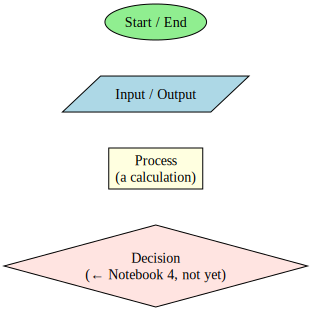

In [13]:
legend = Digraph(graph_attr={"rankdir": "TB"})
legend.node("S", "Start / End", shape="ellipse",
            style="filled", fillcolor="lightgreen")
legend.node("I", "Input / Output", shape="parallelogram",
            style="filled", fillcolor="lightblue")
legend.node("P", "Process\n(a calculation)", shape="box",
            style="filled", fillcolor="lightyellow")
legend.node("D", "Decision\n(← Notebook 4, not yet)", shape="diamond",
            style="filled", fillcolor="mistyrose")
legend.edge("S", "I", style="invis")
legend.edge("I", "P", style="invis")
legend.edge("P", "D", style="invis")
legend

**Reading it:** ellipse = Start/End, parallelogram = Input/Output, rectangle = a Process step. The diamond (Decision) is shown greyed-out as a preview — you'll use it in Notebook 4.

### Step 1 — The Problem

Betsey Trotwood brings the counting-house a job:

> *An estate worth a whole number of pounds must be divided **evenly** among the heirs. Each heir gets an equal whole-pound share. Any pounds that don't divide evenly are held back by the estate. Report each heir's share and the amount held back.*

Pinned down precisely:

- **Inputs:** `total` (whole pounds, an integer), `heirs` (a count, an integer)
- **Outputs:** `share` (whole pounds per heir), `leftover` (pounds held back)
- **Relationship:** the *"how many whole groups, and how much left over"* question — `//` and `%`.

### Step 2 — Pseudocode

```text
ALGORITHM: split_estate
INPUT:   total  — the estate value in whole pounds
         heirs  — the number of heirs
OUTPUT:  share     — whole pounds each heir receives
         leftover  — pounds that cannot be divided evenly

1. READ total
2. READ heirs
3. SET share    = total // heirs      (whole pounds each)
4. SET leftover = total % heirs       (the remainder)
5. PRINT share
6. PRINT leftover
```

Six numbered steps, plain language, no Python syntax. Anyone could follow this — including a future you debugging at midnight.

### Step 2½ — The Flowchart

Same six steps as the pseudocode, drawn as a picture so the straight-line shape is obvious: Start, two inputs, two calculations, one output, End.

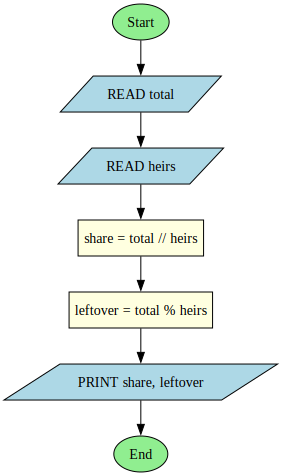

In [14]:
fc = Digraph(graph_attr={"rankdir": "TB"})
fc.node("S",  "Start",                    shape="ellipse",
        style="filled", fillcolor="lightgreen")
fc.node("R1", "READ total",               shape="parallelogram",
        style="filled", fillcolor="lightblue")
fc.node("R2", "READ heirs",               shape="parallelogram",
        style="filled", fillcolor="lightblue")
fc.node("P1", "share = total // heirs",   shape="box",
        style="filled", fillcolor="lightyellow")
fc.node("P2", "leftover = total % heirs", shape="box",
        style="filled", fillcolor="lightyellow")
fc.node("O",  "PRINT share, leftover",    shape="parallelogram",
        style="filled", fillcolor="lightblue")
fc.node("E",  "End",                      shape="ellipse",
        style="filled", fillcolor="lightgreen")
fc.edges([("S","R1"), ("R1","R2"), ("R2","P1"),
          ("P1","P2"), ("P2","O"), ("O","E")])
fc

**Reading it:** the flow runs top to bottom with no branches — every estate split is the same actions in the same order. That's what "sequential" looks like; Notebook 4 adds the first fork.

### Step 3 — Python

Translate the pseudocode **line for line**. Editable values first, so the output is reproducible and we can check it by hand; the interactive version comes right after.

In [15]:
# ⬇️ CHANGE THESE, THEN RE-RUN
total = 1000        # step 1: READ total
heirs = 7           # step 2: READ heirs
# ----------------------------------

share    = total // heirs      # step 3
leftover = total % heirs       # step 4

print(f"Each heir receives £{share}.")               # step 5
print(f"£{leftover} is held back by the estate.")    # step 6

Each heir receives £142.
£6 is held back by the estate.


### Step 4 — Verify by Hand

Never trust output you haven't checked. With `total = 1000`, `heirs = 7`:

- `1000 // 7` → 7 goes into 1000 **142** times (142 × 7 = 994)
- `1000 % 7` → leftover is `1000 − 994 =` **6**
- **Cross-check:** 142 × 7 + 6 = 994 + 6 = **1000** ✓ — shares plus held-back must equal the whole estate. They do.

This `(quotient × divisor) + remainder = original` check works for *any* `//` and `%` pair. Use it on the quiz.

In [16]:
# The real version: ask the user. Note int(...) around each input —
# without it, total and heirs are strings and // would error.
total = int(input("Estate value in whole pounds: "))
heirs = int(input("Number of heirs: "))

share    = total // heirs
leftover = total % heirs

print(f"Each heir receives £{share}.")
print(f"£{leftover} is held back by the estate.")

Each heir receives £810.
£3 is held back by the estate.


The interactive version is just the pseudocode with `int(input(...))` wired into steps 1–2 — the type-casting rule applied. The *thinking* was finished before a line of Python was written. That is the entire method.

### ✏️ Exercise 2 — Run the Whole Pipeline

Take this through **all four steps** yourself.

> *Cratchit is owed a number of whole pennies. Convert it to pounds and leftover pennies, where 1 pound = 100 pennies. Report the pounds and the pennies.*

1. **Problem:** write down inputs and outputs.
2. **Pseudocode:** in a markdown cell, house conventions.
3. **Flowchart:** describe it in words, *or* copy the graphviz cell above and adapt it.
4. **Python:** in a code cell with an editable value block, then **verify by hand** with one example (show the cross-check).

No solution is provided — that's the point. *Hint: same `//` and `%` shape as the estate split.*

### ✏️ Exercise 3 — Translate My Pseudocode &nbsp; 🤖 *AI-Assisted*

1. Write **pseudocode** (only — no Python yet) for this problem:

   > *A shopkeeper takes a price in pounds and a whole-number percentage discount. Compute and print the amount saved and the final price, both to 2 decimals.*

2. Paste your pseudocode into Gemini: *"Translate this pseudocode into Python. Do not add features I didn't specify."*
3. Run the AI's code in a new cell. **Verify it** against a hand-calculation you do yourself (e.g., £80 at 25% off → saved £20.00, final £60.00).
4. In a markdown cell: did it match? Name **one** thing the AI got wrong, added uninvited, or could improve — and fix it.

The skill being graded is the *verification*, not the AI's first draft.

## Building With AI (Plan First, Then Code)

Notebook 1 ended on this: an AI predicts *plausible-looking* text. The defence isn't to avoid AI — it's to **do the thinking first** and use the AI to pressure-test your thinking.

A verification checklist for any code (yours or an AI's):

1. **Does it run?** Errors are the easy case — Python tells you.
2. **Test a known input.** Feed it something you worked out by hand. Does it match?
3. **Read every line.** Is `input()` cast with `int()`? Is it `//` or `/`? Is it `==` or `=`?
4. **Does it match the pseudocode?** Without a plan to compare against, you only know it didn't crash — not that it's right.

### ✏️ Exercise 4 — Build a Counting-House Report (Capstone) &nbsp; 🤖 *AI-Assisted*

Build **one** of these. Both are sequential and use the printing tools from this notebook:

- **Cratchit's Pay Receipt** *(recommended)* — inputs: `hours`, `rate`, `advance` (money already taken). Compute gross pay (`hours × rate`) and amount due (`gross − advance`). Print a formatted receipt: a repeated-character rule, a centred upper-cased firm banner, left-aligned labels, and a right-aligned money column to 2 decimals.
- **The Counting-House Calling Card** *(lighter on maths)* — inputs: `name`, `title`, `firm`. Print a bordered card: the name title-cased and centred, the border drawn with string repetition sized so it always fits.

**Follow the workflow — this is what's being graded:**

1. **Write pseudocode by hand** in a markdown cell (house conventions). No Python yet.
2. **Ask the AI to critique your pseudocode**, not write code: *"Here is my pseudocode for X. What's missing, unclear, or out of order? Do not write any code."*
3. **Revise your pseudocode** based on the critique.
4. **Translate it to Python yourself** in the scaffold cell below.
5. **Test** by editing the value block (checklist steps 1–2), then **reflect** in a markdown cell: what did the AI's critique catch that you missed?

In [17]:
# ✏️ Exercise 4 — build your report here, AFTER writing and revising pseudocode.

# ⬇️ CHANGE THESE, THEN RE-RUN
hours   = 40
rate    = 1.25
advance = 5.00
# ----------------------------------

# TODO: translate YOUR revised pseudocode into Python below.
# Use the printing toolkit: f-strings, :.2f, alignment (:^ :< :>),
# escape characters, and "-" * n for separator lines.


## Key Terms

- **Variable** — A named box that holds one value.
- **Assignment (`=`)** — Stores the right-hand value into the variable; read it as "gets."
- **Data type** — The kind of a value: `int`, `float`, `str`, `bool`.
- **int / float** — Whole number vs. number with a decimal point.
- **str / bool** — Text in quotes; a truth value (`True`/`False`).
- **Expression / statement** — Code that computes a value vs. a complete instruction.
- **Operator / operand** — The verb (`+`, `//`, `and`) and the values it acts on.
- **Floor division (`//`) / modulo (`%`)** — Whole part of a division / the remainder.
- **Comparison operators** — `== != < > <= >=`; each produces a `bool`.
- **Boolean operators** — `and`, `or`, `not`; combine truth values.
- **Operator precedence** — The order operators resolve: arithmetic → comparison → `not` → `and` → `or`.
- **Type casting** — Deliberately converting a value's type, e.g. `int("5")`.
- **Escape character** — A backslash code inside a string: `\n`, `\t`, `\"`, `\\`.
- **f-string / format specifier** — `f"..."` text with `{var}`; `:.2f`, `:>10`, `:,` control how a value prints.
- **String method** — A function called on a string with a dot: `.upper()`, `.strip()`, `.replace()`.
- **Pseudocode** — Structured, language-neutral plain English describing an algorithm.
- **Flowchart** — A diagram of an algorithm: ellipse = start/end, parallelogram = I/O, box = process, diamond = decision.
- **Trace** — To run code in your head, line by line, predicting each result.
- **Comment (`#`)** — A note for humans; Python ignores it.

## Summary

- A **variable** is a named box; `=` stores into it, and the **right side runs first**.
- Every value has a **type**; quotes always mean `str`, and `input()` always returns `str`.
- `/` always gives a `float`; `//` and `%` answer *"how many whole groups, how much left over."*
- **Boolean** expressions follow precedence; evaluate the innermost, simplest part first.
- **Printing well** = escape characters + f-string specifiers (`:.2f`, alignment) + string methods + repetition.
- The course workflow is **problem → pseudocode → flowchart → Python → verify**. Plan by hand; let the AI critique the *plan*, not hand you the answer.

Write it down before you write it up. Esther Summerson would insist.

## What's Next

Every program here ran straight down, top to bottom. **Notebook 4** brings the shape greyed-out in our flowchart legend: the **decision diamond**. Programs will start making choices and repeating work — `if`, `else`, and loops. Madame Defarge keeps her records by knitting the same stitch over and over; soon you'll write the loop that does it for her.

*COMP 1150 — Computer Science Concepts · Brendan Shea, PhD*  
*Content licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*